In [265]:
gen_report = False

In [266]:
import os
import json
import pandas as pd

root = "experiments"

records = []

for dirpath, dirnames, filenames in os.walk(root):
    if "report.json" in filenames:
        report_path = os.path.join(dirpath, "report.json")

        with open(report_path, "r") as f:
            data = json.load(f)

        record = {}

        record["VQEL"] = data.get("VQEL")

        # metrics
        for k, v in data.get("metrics", {}).items():
            record[k] = v

        # config
        for k, v in data.get("config", {}).items():
            if 'dir' in k.lower() or 'split' in k.lower():
                continue
            record[k] = v

        record["path"] = dirpath.replace('experiments/', '').replace('/results', '')
        records.append(record)

df = pd.DataFrame(records)
# df.to_csv('VQTT_results.csv', index=False)
# df = pd.read_csv('VQTT_results.csv')
# df.to_pickle('VQTT_results.pkl')
# df = pd.read_pickle('VQTT_results.pkl')

df["reset_unfrozen_params"] = df["reset_unfrozen_params"].map({True: "yes", False: "no"})
df["freeze_codebook"] = df["freeze_codebook"].map({True: "yes", False: "no"})
df["freeze_object_encoder"] = df["freeze_object_encoder"].map({True: "yes", False: "no"})

df.loc[df["num_iterations"] == 0, "learning_rate_tt"] = "-"
df.loc[df["agent_a_training_mode"] == 'frozen', "learning_rate_phase2_a"] = "-"
df.loc[df["best_of_n"].isna(), "best_of_n"] = 1
df.loc[df["dataset_tt"].isna(), "dataset_tt"] = "one_shape"
df.loc[df["sampling_temperature_tt"].isna(), "sampling_temperature_tt"] = df["sampling_temperature"]
df.loc[df["gumbel"].isna(), "gumbel"] = False

df.loc[(df["num_iterations"] == 0) | (df["best_of_n"] == 1), "test_time_mode"] = "-"

df.rename(columns={"test_time_training_accuracy": "test_time_mutual_accuracy"}, inplace=True)
df.rename(columns={"test_time_self_play_accuracy": "test_time_self_accuracy"}, inplace=True)

df["test_time_mode"] = df["test_time_mode"].replace("adaptation", "sample_adaptation")
df["dataset"] = df["dataset"].replace("shape", "shape1")
df["dataset_tt"] = df["dataset_tt"].replace("two_shape", "shape2")
df["dataset_tt"] = df["dataset_tt"].replace("shape_unique_double_attribute", "dual_attribute_shape")
# df["dataset_tt"] = df["dataset_tt"].replace("shape_unique_double_attribute", "single_attribute_shape")

df.loc[df["baseline"].isna(), "baseline"] = False

df.loc[df["baseline"], "test_time_mode"] = "-"

df["test_time_mutual_accuracy"] = df["test_time_mutual_accuracy"] * 100
df["test_time_self_accuracy"] = df["test_time_self_accuracy"] * 100
df["mutual_play_accuracy"] = df["mutual_play_accuracy"] * 100
df["self_play_accuracy_a"] = df["self_play_accuracy_a"] * 100

df = df.where(pd.notna(df), "None")
pd.options.display.float_format = '{:.10g}'.format
df = df.map(lambda x: f"{x:.0e}" if isinstance(x, (int, float)) and x != 0 and (abs(x) < 0.01 or abs(x) == 0.1 or abs(x) == 0.01) else x)
print("Total reports loaded:", len(df))

pd.set_option('display.max_rows', None)

Total reports loaded: 6683


/tmp/ipykernel_604511/3750467460.py:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df["num_iterations"] == 0, "learning_rate_tt"] = "-"
/tmp/ipykernel_604511/3750467460.py:44: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df["agent_a_training_mode"] == 'frozen', "learning_rate_phase2_a"] = "-"


In [267]:
def filter_df(filters, df=df, sort_by=["message_length", "message_length_tt", "learning_rate_tt", "num_iterations"]):

    idx = pd.Series(True, index=df.index)

    for key, values in filters.items():
        mask = pd.Series(False, index=df.index)
        if not isinstance(values, (list, tuple, set)):
            values = [values]
        for value in values:
            if (type(value) == str) and value.startswith('>'):
                mask |= (df[key] > value.split('>')[1])
            if value == "!None":
                mask |= (df[key] != "None")
            else:
                mask |= (df[key] == value)
        idx &= mask 

    return df[idx].sort_values(by=sort_by).reset_index(drop=True)

    

In [268]:
import base64

def to_html(df):    

    # ---- highlight rule ----
    # if 'mutual_play_accuracy' in df:
    #     max_col = 'mutual_play_accuracy'
    # else:
    #     max_col = 'test_accuracy'
    # max_val = pd.to_numeric(df[max_col]).max()

    # def highlight_max_row(row):
    #     if  pd.to_numeric(row[max_col]) == max_val:
    #         return ['font-weight: bold; background-color: #ffff99'] * len(row)
    #     else:
    #         return [''] * len(row)

    # ---- style ----
    styled = (
        df.style
            # .apply(highlight_max_row, axis=1)  # <<< APPLY HIGHLIGHT HERE
            .hide(axis="index")
            .format(
                lambda x: (
                    f"{int(x)}"                      # 20.0 -> 20
                    if isinstance(x, float) and x.is_integer()
                    else f"{x:.0e}"                  # small numbers -> scientific
                    if isinstance(x, (int, float)) and x != 0 and abs(x) < 0.01
                    else x
                )
            )
            .set_table_styles([
                {"selector": "td", "props": [("border-right", "1px solid black")]},
                {"selector": "th", "props": [
                    ("border-right", "1px solid black"),
                    ("color", "darkblue"),
                    ("font-weight", "bold"),
                    ("padding-left", "8px"),
                    ("padding-right", "8px")
                ]},
            ])
            .set_properties(**{"text-align": "center"})
    )

    html_table = styled.to_html(index=False)

    if gen_report:
        with open("results.html", "a") as f:
            f.write(html_table)

        
def add_heading(num=1, title=""):
    """Add a professional-colored heading to results.html"""
    colors = ["#0b3d91",  # dark blue
              "#800000",  # maroon
              "#205522",  # dark green
              "#111011",  # indigo
              "#444444"]  # dark gray
    color = colors[(num-1) % len(colors)]  # cycle through colors
    
    if gen_report:
        with open("results.html", "a") as f:
            f.write(f'<h{num} style="color:{color}; font-family:Arial, sans-serif;">{title}</h{num}>\n')
        
def clear():
    if gen_report:
        with open("results.html", "w") as f:
            f.write("")

def line():
    if gen_report:
        with open("results.html", "a") as f:
            f.write('<hr style="border:1px solid #444; margin:10px 0;">\n')
        
        
def write(text):
    html_text = text.replace("\n", "<br>\n")
    
    if gen_report:
        with open("results.html", "a") as f:
            f.write(f"{html_text}\n")


def add_plot(path="plot.png"):
    """Embed an image file directly into results.html using base64."""
    with open(path, "rb") as img:
        encoded = base64.b64encode(img.read()).decode("utf-8")

    html_img = (
        '<img src="data:image/png;base64,' +
        encoded +
        '" style="max-width:650px; height:auto;"><br>\n'
    )

    if gen_report:
        with open("results.html", "a") as f:
            f.write(html_img)
        
    if os.path.exists(path):
        os.remove(path)

In [269]:
import os
import shutil

def remove_expr(res_df):
    for path in res_df["path"]:
        full_path = os.path.join("experiments", path)

        if not os.path.isdir(full_path):
            print(f"[SKIP] Not found: {full_path}")
            continue

        answer = input(f"⚠️ Delete expr '{path}' ? (y/n): ").strip().lower()

        if answer == "y":
            shutil.rmtree(full_path)
            print(f"✅ Deleted: {path}")
        else:
            print(f"❌ Skipped: {path}")

In [270]:
metrics = [
    # "unique_messages"
]

In [271]:
from itertools import product
import pandas as pd


def extract_maxes(df, cols=["message_length", "message_length_tt", "seed"], max_col="test_time_self_accuracy"):
    values = []
    for col in cols:
        value = set(df[col])
        values.append(value)

    combinations = [list(x) for x in product(*values)]

    maxes = []
    for comb in combinations:
        section = filter_df({col: value for col, value in zip(cols, comb)}, df)
        if not section.empty:
            max_row = section.loc[pd.to_numeric(section[max_col]).idxmax()]
            maxes.append(max_row.to_frame().T)

    final_df = pd.concat(maxes, ignore_index=True)
    return final_df.sort_values(by=cols).reset_index(drop=True)


def mean_and_std(df, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode"], metrics=["test_time_self_accuracy", "test_time_mutual_accuracy"] + metrics, precision=1):
    rows = []

    for i in range(0, len(df), 3):
        chunk = df.iloc[i:i+3]
        
        rows.append(
            {col: chunk[col].iloc[0] for col in config_cols} | 
            # {metric: f"{pd.to_numeric(chunk[metric]).mean() * 100:.1f} ± {pd.to_numeric(chunk[metric]).std() * 100:.1f}" for metric in metrics}
            {
            metric: (
                None
                if pd.to_numeric(chunk[metric], errors="coerce").dropna().empty
                else f"{pd.to_numeric(chunk[metric], errors='coerce').mean():.{precision}f} ± "
                     f"{pd.to_numeric(chunk[metric], errors='coerce').std():.{precision}f}"
            )
            for metric in metrics
        }
        )

    out = pd.DataFrame(rows)
    return out.sort_values(by=config_cols)
    

In [272]:
f"{0.23732: .2f}"

' 0.24'

In [273]:
def smooth(values, factor=0.5):
    """Exponential moving average smoothing."""
    smoothed = []
    s = values[0]
    for v in values:
        s = factor * s + (1 - factor) * v
        smoothed.append(s)
    return smoothed

In [274]:
import matplotlib.pyplot as plt

METHOD_COLORS = {
    "GS-ST": "#8c2d04",
    "REINFORCE": "#1f77b4",
    "VQEL": "#ff7f0e",
    "VQEL + TTA (Batch)": "#2ca02c",
    "VQEL + TTA (Dataset)": "#9467bd",
    "Scaling": "#7f7f7f",
    "LR = 1e-4": "#8c2d04",
    "LR = 1e-5": "#7f7f7f",
    "LR = 1e-6": "#2ca02c",
}


def plot(
    dfs,
    labels=("GS-ST", "REINFORCE", "VQEL", "VQEL + TTA (Batch)", "VQEL + TTA (Dataset)", "Scaling"),
    name="name",
    xcol="message_length_tt",
    xlabel="Message Length",
    marker="o",
    smooth_factor=0,
    xticks=None,
    logscale=False,
    base=10,
    grid=True
    ):
    fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

    all_x = []

    for df, label in zip(dfs, labels):
        if label not in METHOD_COLORS:
            raise ValueError(f"No color defined for label: {label}")

        color = METHOD_COLORS[label]

        df = df.copy()

        # Split "mean ± std"
        df[["mean_acc", "std_acc"]] = (
            df["test_time_mutual_accuracy"]
            .str.split("±", expand=True)
            .astype(float)
        )

        df = df.sort_values(xcol)

        x = df[xcol]
        y = df["mean_acc"]
        err = df["std_acc"]

        all_x.extend(x.tolist())

        ax.plot(
            x,
            smooth(y, factor=smooth_factor),
            marker=marker,
            linewidth=2,
            color=color,
            label=label,
        )

        ax.fill_between(
            x,
            smooth(y - err, factor=smooth_factor),
            smooth(y + err, factor=smooth_factor),
            color=color,
            alpha=0.2,
            linewidth=0,
        )

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("Accuracy on OOD Split (\%)", fontsize=12)

    if xticks == None:
        xticks = sorted(set(all_x))
    ax.set_xticks(xticks)
    
    ax.tick_params(axis="both", labelsize=10)

    ax.legend(frameon=False)
    if grid:
        ax.grid(alpha=0.3)
    
    if logscale:
        ax.set_xscale('log', base=base)
    fig.tight_layout()

    plt.savefig(
        f"assets/{name}.pdf",
        format="pdf",
        bbox_inches="tight",
    )

    plt.show()
    

In [275]:
clear()

---

In [276]:

gumbel_cols = [
    "seed",
    "baseline",
    "dataset",
    "sim",
    "message_length",
    "learning_rate_phase2_a", 
    "learning_rate_phase2_b",
    "tau_0",
    "mutual_play_accuracy",
    "sampling_temperature",
    "test_time_mode",
    "path",
]

backbone_cols = [
    "seed",
    "baseline",
    "dataset",
    "sim",
    "message_length",
    "learning_rate_phase1", 
    "learning_rate_phase2_a", 
    "learning_rate_phase2_b",
    "test_time_mode",
    "self_play_accuracy_a",
    "mutual_play_accuracy",
    "path",
]

backbone_cols_report = [
    "seed",
    "message_length",
    "agent_a_training_mode",
    "self_play_accuracy_a",
    "mutual_play_accuracy",
]

baseline_cols = [
    "seed",
    "baseline",
    "dataset",
    "sim",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
] + metrics + [
    "path",
]

baseline_cols_report = [
    "seed",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
]

scaling_cols = [
    "seed",
    "baseline",
    "dataset",
    "sim",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "sampling_temperature_tt",
    "best_of_n",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
    "path",
]

scaling_cols_report = [
    "seed",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "sampling_temperature_tt",
    "best_of_n",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
]

adapt_cols = [
    "seed",
    "baseline",
    "dataset",
    "sim",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "learning_rate_tt",
    "num_iterations",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
    "path",
]

adapt_cols_report = [
    "seed",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "learning_rate_tt",
    "num_iterations",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
]

In [277]:
write(
"""
- <b>Shape1</b>: Contains only one shape.

- <b>Shape2</b>: Contains exactly two shapes.

- <b>Shape12</b>: Contains one or two shapes.

- <b>MNIST1</b>: Contains one digit on either the left or right side of the image (the other side is empty).

- <b>MNIST2</b>: Contains two digits.

- <b>ImageNet_same_class</b>: Distractors and targets belong to the same class.

- <b>Single Attribute Shape</b>: Candidates in a batch have two attributes; the value of one attribute is different for all images,
while there is no restriction on the value of the other attribute—it may be the same for some images and different for others.

- <b>Dual-attribute shape</b>: Candidates in a batch have two attributes, and all candidates can be distinguished from one another 
if and only if the values of both attributes are described.
"""
)

# Shape

## Gumbel - ID

In [278]:
res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "dialogued_checkpoint": "None",
    "baseline": True,
    "gumbel": True
}, sort_by=["seed"])
# res[gumbel_cols]

In [279]:
final = extract_maxes(res, max_col="mutual_play_accuracy")
# final[gumbel_cols]

In [280]:
mean = mean_and_std(final, config_cols = ["dataset", "message_length"], metrics = ["mutual_play_accuracy"])
to_html(mean)
mean

,dataset,message_length,mutual_play_accuracy
0,shape1,"[3, 4]",84.2 ± 0.8


## Gumbel - OOD

In [281]:
res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "dialogued_checkpoint": "!None",
    "baseline": True,
    "gumbel": True,
}, sort_by=["message_length_tt", "seed"])
# res[baseline_cols]

In [282]:
gumbel = mean_and_std(res, metrics=["test_time_self_accuracy", "test_time_mutual_accuracy", "unique_messages"])
# gumbel

## REINFORCE - ID

In [283]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "dialogued_checkpoint": "None",
    "baseline": True,
    "gumbel": False
}, sort_by=["seed"])
# res[backbone_cols]

In [284]:
mean = mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["mutual_play_accuracy"])
to_html(mean)
mean

,dataset,message_length,mutual_play_accuracy
0,shape1,"[3, 4]",86.5 ± 0.2


## REINFORCE - OOD

In [285]:
res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "dialogued_checkpoint": "!None",
    "baseline": True,
    "gumbel": False
}, sort_by=["message_length_tt", "seed"])
# res[baseline_cols]

In [286]:
REINFORCE = mean_and_std(res)
# REINFORCE

## VQEL - ID

In [287]:
add_heading(2, "Shape1")
add_heading(3, "Base Model")

res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "baseline": False,
    "message_length": "[3, 4]",
    "test_time_mode": "-",
    "dialogued_checkpoint": "None",
}, sort_by=["message_length"])
res = extract_maxes(res, max_col="mutual_play_accuracy")
# res[backbone_cols]

In [288]:
mean = mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["self_play_accuracy_a", "mutual_play_accuracy"])
to_html(mean)
mean

,dataset,message_length,self_play_accuracy_a,mutual_play_accuracy
0,shape1,"[3, 4]",84.1 ± 0.5,88.7 ± 0.2


## VQEL - OOD

In [289]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "dataset_tt": "shape2",
    "baseline": False,
    "message_length": "[3, 4]",
    "test_time_mode": "-"
}, sort_by=["message_length_tt", "seed"])

to_html(res[baseline_cols_report])

# res[baseline_cols]

In [290]:
VQ_NoTT = mean_and_std(res)
# VQ_NoTT

## Scaling

In [291]:
add_heading(3, "Scaling")

res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "VQEL": True,
    "message_length": "[3, 4]",
    "test_time_mode": "scaling"
}, sort_by=["message_length", "message_length_tt", "seed", "sampling_temperature_tt", "best_of_n"])

to_html(res[scaling_cols_report])

# res[scaling_cols]

In [292]:
final = extract_maxes(res)
# final[scaling_cols]

In [293]:
scaling = mean_and_std(final)
# scaling

## Batch Adaptation

In [294]:
add_heading(3, "Adaptation")

res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "VQEL": True,
    "message_length": "[3, 4]",
    "test_time_mode": ["batch_adaptation"],
}, sort_by=["message_length_tt","seed", "learning_rate_tt"])

# res[adapt_cols]

In [295]:
final = extract_maxes(res)
# final[adapt_cols]

In [296]:
batch_adapt = mean_and_std(final)
# batch_adapt

## Dataset Adaptation

In [297]:
res = filter_df({
    "dataset": "shape1",
    "sim": "cosine",
    "VQEL": True,
    "message_length": "[3, 4]",
    "test_time_mode": ["dataset_adaptation"],
}, sort_by=["message_length_tt","seed", "learning_rate_tt"])
# res[adapt_cols]

In [298]:
final = extract_maxes(res)
# final[adapt_cols]

In [299]:
dataset_adapt = mean_and_std(final)
# dataset_adapt

## Plot

In [300]:
# plot([gumbel, REINFORCE, VQ_NoTT, batch_adapt, dataset_adapt], name="shape")

In [301]:
# plot([gumbel, REINFORCE, VQ_NoTT, batch_adapt, scaling], labels=("GS-ST", "REINFORCE", "VQEL", "VQEL + TTA (Batch)", "Scaling"),name="shape-scaling")

# MNIST

## Gumbel - ID

In [302]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "dialogued_checkpoint": "None",
    "gumbel": True,
    "number_of_candidates": 100,
    "message_length": "[3, 4]"
}, sort_by=["seed"])

# res[gumbel_cols]

In [303]:
final = extract_maxes(res, max_col="mutual_play_accuracy")
final[gumbel_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase2_a,learning_rate_phase2_b,tau_0,mutual_play_accuracy,sampling_temperature,test_time_mode,path
0,1,True,mnist1,cosine,"[3, 4]",-,1e-05,1e-01,80.8,1e-05,-,20260212_1441_bs32_vocab10_repr192_msg_len4_lr...
1,2,True,mnist1,cosine,"[3, 4]",-,1e-05,1e-01,80.3,1e-05,-,20260216_2326_bs32_vocab10_repr192_msg_len4_lr...
2,3,True,mnist1,cosine,"[3, 4]",-,1e-05,0.3,79.4,1e-05,-,20260217_1444_bs32_vocab10_repr192_msg_len4_lr...


In [304]:
mean = mean_and_std(final, config_cols = ["dataset", "message_length"], metrics = ["mutual_play_accuracy"])
to_html(mean)
mean

,dataset,message_length,mutual_play_accuracy
0,mnist1,"[3, 4]",80.2 ± 0.7


## Gumbel - OOD

In [305]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "dialogued_checkpoint": "!None",
    "gumbel": True,
    "number_of_candidates": 100,
}, sort_by=["message_length_tt", "seed"])
# res[baseline_cols]

In [306]:
gumbel = mean_and_std(res)
# gumbel

## REINFORCE - ID

In [307]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "dialogued_checkpoint": "None",
    "gumbel": False,
    "number_of_candidates": 100,
    "message_length": "[3, 4]"
}, sort_by=["seed"])
res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,True,mnist1,cosine,"[3, 4]",1e-04,-,1e-04,-,0,92.5,20251230_1620_bs32_vocab10_repr192_msg_len4_lr...
1,2,True,mnist1,cosine,"[3, 4]",1e-04,-,1e-04,-,0,85.8,20251230_1705_bs32_vocab10_repr192_msg_len4_lr...
2,3,True,mnist1,cosine,"[3, 4]",1e-04,-,1e-04,-,0,88.2,20251230_1750_bs32_vocab10_repr192_msg_len4_lr...


In [308]:
mean_and_std(res)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,mnist1,"[3, 4]",4,mnist1,-,0.0 ± 0.0,86.9 ± 2.3


## REINFORCE - OOD

In [309]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "dialogued_checkpoint": "!None",
    "gumbel": False,
    "number_of_candidates": 100,
}, sort_by=["message_length_tt", "seed"])
# res[baseline_cols]

In [310]:
REINFORCE = mean_and_std(res)
# REINFORCE

## VQEL - ID

In [311]:
add_heading(2, "MNIST")
add_heading(3, 'Base Model')
res = filter_df({
    "dataset": "mnist1",
    "sim": "cosine",
    "baseline": False,
    "test_time_mode": "-",
    "dataset_tt": "mnist1",
    "message_length": "[3, 4]",
    "number_of_candidates": 100,
}, sort_by=["message_length", "message_length_tt"])
res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,False,mnist1,cosine,"[3, 4]",1e-04,-,1e-04,-,78.8,89.5,20251223_1750_bs32_vocab10_repr192_lr1_0.0001_...
1,2,False,mnist1,cosine,"[3, 4]",1e-04,-,1e-04,-,78.7,89.1,20251228_1548_bs32_vocab10_repr192_msg_len10_l...
2,3,False,mnist1,cosine,"[3, 4]",1e-04,-,1e-04,-,79.9,91.8,20251228_1637_bs32_vocab10_repr192_msg_len10_l...


In [312]:
mean = mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["self_play_accuracy_a", "mutual_play_accuracy"])
mean

,dataset,message_length,self_play_accuracy_a,mutual_play_accuracy
0,mnist1,"[3, 4]",79.1 ± 0.7,90.1 ± 1.5


## VQEL - OOD

In [313]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "mnist1",
    "sim": "cosine",
    "dataset_tt": "mnist2",
    "baseline": False,
    "test_time_mode": "-",
    "number_of_candidates": 100,
}, sort_by=["message_length", "message_length_tt", "seed"])
# res[baseline_cols]

In [314]:
final = extract_maxes(res)
# final[baseline_cols]

In [315]:
VQ_NoTT = mean_and_std(final)
# VQ_NoTT

## Scaling

In [316]:
add_heading(3, "Scaling")
res = filter_df({
    "dataset": "mnist1",
    "sim": "cosine",
    "baseline": False,
    "test_time_mode": "scaling",
    "sampling_temperature_tt": "1e-02",
    "number_of_candidates": 100,
}, sort_by=["message_length", "message_length_tt", "sampling_temperature_tt", "best_of_n"])
# res[scaling_cols]

In [317]:
final = extract_maxes(res)
# final[scaling_cols]

In [318]:
scaling = mean_and_std(final)
# scaling

## Batch Adaptation

In [319]:
add_heading(3, "Adaptation")

res = filter_df({
    "dataset": "mnist1",
    "VQEL": True,
    "test_time_mode": ["batch_adaptation"],
    "number_of_candidates": 100,
}, sort_by=["message_length_tt", "seed", "learning_rate_tt", "num_iterations"])

# res[adapt_cols]

In [320]:
final = extract_maxes(res)
# final[adapt_cols]

In [321]:
batch_adapt = mean_and_std(final)
# batch_adapt

## Dataset Adaptation

In [322]:
add_heading(3, "Adaptation")

res = filter_df({
    "dataset": "mnist1",
    "VQEL": True,
    "test_time_mode": ["dataset_adaptation"],
    "number_of_candidates": 100,
}, sort_by=["message_length_tt", "seed", "learning_rate_tt", "num_iterations"])

# res[adapt_cols]

In [323]:
final = extract_maxes(res, max_col="test_time_self_accuracy")
# final[adapt_cols]

In [324]:
dataset_adapt = mean_and_std(final)
# dataset_adapt

## Plot

In [325]:
# plot([gumbel, REINFORCE, VQ_NoTT, batch_adapt, dataset_adapt], name="mnist")

In [326]:
# plot([gumbel, REINFORCE, VQ_NoTT, batch_adapt, scaling], labels=("GS-ST", "REINFORCE", "VQEL", "VQEL + TTA (Batch)", "Scaling"),name="mnist-scaling")

# ImageNet

## Gumbel - ID

In [327]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "imagenet",
    "baseline": True,
    "message_length": "[2, 3, 4]",
    "dialogued_checkpoint": "None",
    "gumbel": True,
}, sort_by=["message_length", "seed"])
# res[gumbel_cols]

In [328]:
final = extract_maxes(res, max_col="mutual_play_accuracy")
final[gumbel_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase2_a,learning_rate_phase2_b,tau_0,mutual_play_accuracy,sampling_temperature,test_time_mode,path
0,1,True,imagenet,cosine,"[2, 3, 4]",-,1e-05,1e-01,72.6,1,-,20260214_1231_bs32_vocab10_repr2048_msg_len4_l...
1,2,True,imagenet,cosine,"[2, 3, 4]",-,1e-05,1e-01,73.6,1e-05,-,20260217_0025_bs32_vocab10_repr2048_msg_len4_l...
2,3,True,imagenet,cosine,"[2, 3, 4]",-,1e-05,1e-01,74.4,1e-05,-,20260217_0215_bs32_vocab10_repr2048_msg_len4_l...


In [329]:
mean = mean_and_std(final, config_cols = ["dataset", "message_length"], metrics = ["mutual_play_accuracy"])
mean

,dataset,message_length,mutual_play_accuracy
0,imagenet,"[2, 3, 4]",73.5 ± 0.9


## Gumbel - OOD

In [330]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": True,
    "dialogued_checkpoint": "!None",
    "gumbel": True,
    "dataset_tt": "imagenet_same_class",
}, sort_by=["message_length_tt", "seed"])
# res[baseline_cols]

In [331]:
gumbel = mean_and_std(res, metrics=["test_time_self_accuracy", "test_time_mutual_accuracy"] + metrics)
# gumbel

## REINFORCE - ID

In [332]:
add_heading(3, "Baseline")

res = filter_df({
    "dataset": "imagenet",
    "baseline": True,
    "message_length": "[2, 3, 4]",
    "dialogued_checkpoint": "None",
    "gumbel": False,
}, sort_by=["message_length", "seed"])

res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,True,imagenet,cosine,"[2, 3, 4]",1e-05,-,1e-05,-,0,85.9,20251231_1826_bs32_vocab10_repr2048_msg_len4_l...
1,2,True,imagenet,cosine,"[2, 3, 4]",1e-05,-,1e-05,-,0,84.6,20251231_1934_bs32_vocab10_repr2048_msg_len4_l...
2,3,True,imagenet,cosine,"[2, 3, 4]",1e-05,-,1e-05,-,0,86.9,20251231_1958_bs32_vocab10_repr2048_msg_len4_l...


In [333]:
mean_and_std(res)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,imagenet,"[2, 3, 4]",4,imagenet,-,0.0 ± 0.0,85.8 ± 1.2


## REINFORCE - OOD

In [334]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "baseline": True,
    "message_length": "[2, 3, 4]",
    "dialogued_checkpoint": "!None",
    "gumbel": False,
    "dataset_tt": "imagenet_same_class",
}, sort_by=["message_length_tt", "seed"])
# res[baseline_cols]

In [335]:
final = extract_maxes(res)
# final[baseline_cols]

In [336]:
REINFORCE = mean_and_std(final)
# REINFORCE

## VQEL - ID

In [337]:
add_heading(2, "ImageNet")
add_heading(3, "Base Model")

res = filter_df({
    "dataset": "imagenet",
    "sim": "cosine",
    "baseline": False,
    "test_time_mode": "-",
    "dataset_tt": "imagenet",
    "message_length": "[2, 3, 4]"
}, sort_by=["vocab_size", "message_length","seed", "message_length_tt"])
res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,False,imagenet,cosine,"[2, 3, 4]",1e-04,-,1e-04,-,88.4,89.1,20251231_2027_bs32_vocab10_repr2048_msg_len4_l...
1,2,False,imagenet,cosine,"[2, 3, 4]",1e-04,-,1e-04,-,88.4,90.1,20251231_2046_bs32_vocab10_repr2048_msg_len4_l...
2,3,False,imagenet,cosine,"[2, 3, 4]",1e-04,-,1e-04,-,88.1,89.8,20260101_1131_bs32_vocab10_repr2048_msg_len4_l...


In [338]:
mean = mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["self_play_accuracy_a", "mutual_play_accuracy"])
# mean

## VQEL - OOD

In [339]:
add_heading(3, "Baseline")
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "baseline": False,
    "test_time_mode": "-",
    "message_length": "[2, 3, 4]"
}, sort_by=["message_length", "message_length_tt", "seed"])
# res[baseline_cols]

In [340]:
VQ_NoTT = mean_and_std(res)
# VQ_NoTT

## Scaling

In [341]:
add_heading(3, "Scaling")
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "baseline": False,
    "test_time_mode": 'scaling'
}, sort_by=["message_length_tt", "sampling_temperature_tt", "best_of_n"])
# res[scaling_cols]

In [342]:
final = extract_maxes(res)
# final[scaling_cols]

In [343]:
scaling = mean_and_std(final)
# scaling

## Batch Adaptation

In [344]:
add_heading(3, "Adaptation")
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "baseline": False,
    "test_time_mode": ["batch_adaptation"],
    "message_length": "[2, 3, 4]",
    "num_iterations": [50, 100, 200],
}, sort_by=["test_time_mode", "message_length_tt", "seed", "learning_rate_tt", "num_iterations"])
# res[adapt_cols]

In [345]:
final = extract_maxes(res, max_col= "test_time_mutual_accuracy")
# final[adapt_cols]

In [346]:
batch_adapt = mean_and_std(final)
# batch_adapt

## Dataset Adaptation

In [347]:
add_heading(3, "Adaptation")
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "baseline": False,
    "test_time_mode": ["dataset_adaptation"],
    "message_length": "[2, 3, 4]",
    "num_iterations": [5, 10, 15, 20],
}, sort_by=["test_time_mode", "message_length_tt", "seed", "learning_rate_tt", "num_iterations"])
# res[adapt_cols]

In [348]:
final = extract_maxes(res)
# final[adapt_cols]

In [349]:
dataset_adapt = mean_and_std(final)
# dataset_adapt

## Plot

In [350]:
# plot([gumbel, REINFORCE, VQ_NoTT, batch_adapt, dataset_adapt], name="imagenet")

In [351]:
# plot([gumbel, REINFORCE, VQ_NoTT, batch_adapt, scaling], labels=("GS-ST", "REINFORCE", "VQEL", "VQEL + TTA (Batch)", "Scaling"),name="imagenet-scaling")

# Batch Size

In [352]:
adapt_cols = [
    "seed",
    "baseline",
    "dataset",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "number_of_candidates",
    "learning_rate_tt",
    "num_iterations",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
    "path",
]

baseline_cols = [
    "seed",
    "baseline",
    "dataset",
    "message_length",
    "message_length_tt",
    "dataset_tt",
    "test_time_mode",
    "number_of_candidates",
    "test_time_self_accuracy",
    "test_time_mutual_accuracy",
    "path",
]

## ImageNet

In [353]:
number_of_candidates = [2, 4, 8, 16, 32, 64, 118]

### Gumbel - OOD

In [354]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_dog_breed",
    "baseline": True,
    "gumbel": True,
    "test_time_mode": "-",
    "message_length_tt": 6,
    "number_of_candidates": number_of_candidates,
}, sort_by=["message_length_tt", "number_of_candidates", "seed"])

# res[baseline_cols]

In [355]:
gumbel = mean_and_std(res, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### REINFORCE - OOD

In [356]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_dog_breed",
    "baseline": True,
    "gumbel": False,
    "test_time_mode": "-",
    "message_length_tt": 7,
    "number_of_candidates": number_of_candidates,
}, sort_by=["message_length_tt", "number_of_candidates", "seed"])

# res[baseline_cols]

In [357]:
REINFORCE = mean_and_std(res, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### VQEL - OOD

In [358]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_dog_breed",
    "baseline": False,
    "test_time_mode": "-",
    "message_length_tt": 6,
    "number_of_candidates": number_of_candidates,
}, sort_by=["message_length_tt", "number_of_candidates", "learning_rate_tt", "num_iterations", "seed"])

# res[adapt_cols]

In [359]:
vqel = mean_and_std(res, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])
# vqel

### Batch Adaptation

In [360]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_dog_breed",
    "baseline": False,
    "test_time_mode": "batch_adaptation",
    "number_of_candidates": number_of_candidates,
    "message_length_tt": 5
}, sort_by=["message_length_tt", "number_of_candidates", "learning_rate_tt", "num_iterations", "seed"])
# res[adapt_cols]

In [361]:
final = extract_maxes(res, cols=["number_of_candidates", "seed"])
# final[adapt_cols]

In [362]:
batch_adapt = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### Dataset Adaptation

In [363]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_dog_breed",
    "baseline": False,
    "test_time_mode": "dataset_adaptation",
    "number_of_candidates": number_of_candidates,
    "message_length_tt": 5
}, sort_by=["message_length_tt", "number_of_candidates", "learning_rate_tt", "num_iterations", "seed"])
# res[adapt_cols]

In [364]:
final = extract_maxes(res, cols=["number_of_candidates", "seed"])
# final[adapt_cols]

In [365]:
dataset_adapt = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### Plot

In [366]:
# plot([gumbel, REINFORCE, vqel, batch_adapt,dataset_adapt], labels=["GS-ST", "REINFORCE", "VQEL", "VQEL + TTA (Batch)", "VQEL + TTA (Dataset)"], xlabel="Batch size", xcol="number_of_candidates", name="batch/imagenet_batch")

## MNIST

In [367]:
number_of_candidates = [2, 4, 8, 16, 32, 64, 128]

### Gumbel - OOD

In [368]:
res = filter_df({
    "dataset": "mnist1",
    "dataset_tt": "mnist2",
    "baseline": True,
    "gumbel": True,
    "test_time_mode": "-",
    "message_length_tt": 4,
    "number_of_candidates": number_of_candidates,
}, sort_by=["message_length_tt", "number_of_candidates", "learning_rate_tt", "num_iterations", "seed"])
# res[adapt_cols]

In [369]:
gumbel = mean_and_std(res, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### REINFORCE - OOD

In [370]:
res = filter_df({
    "dataset": "mnist1",
    "dataset_tt": "mnist2",
    "baseline": True,
    "gumbel": False,
    "test_time_mode": "-",
    "message_length_tt": 5,
    "number_of_candidates": number_of_candidates,
}, sort_by=["message_length_tt", "number_of_candidates", "learning_rate_tt", "num_iterations", "seed"])
# res[adapt_cols]

In [371]:
REINFORCE = mean_and_std(res, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### VQEL - OOD

In [372]:
res = filter_df({
    "dataset": "mnist1",
    "dataset_tt": "mnist2",
    "baseline": False,
    "test_time_mode": "-",
    "message_length_tt": 7,
    "number_of_candidates": number_of_candidates,
}, sort_by=["message_length_tt", "number_of_candidates", "learning_rate_tt", "num_iterations", "seed"])

# res[adapt_cols]

In [373]:
final = extract_maxes(res, cols=["number_of_candidates", "seed"])
# final[adapt_cols]

In [374]:
vqel = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### Batch Adaptation

In [375]:
res = filter_df({
    "dataset": "mnist1",
    "dataset_tt": "mnist2",
    "baseline": False,
    "test_time_mode": "batch_adaptation",
    "number_of_candidates": number_of_candidates,
}, sort_by=["message_length_tt", "number_of_candidates", "learning_rate_tt", "num_iterations", "seed"])

# res[adapt_cols]

In [376]:
final = extract_maxes(res, cols=["number_of_candidates", "seed"])
# final[adapt_cols]

In [377]:
batch_adapt = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### Dataset Adaptation

In [378]:
res = filter_df({
    "dataset": "mnist1",
    "dataset_tt": "mnist2",
    "baseline": False,
    "test_time_mode": "dataset_adaptation",
    "number_of_candidates": number_of_candidates,
}, sort_by=["message_length_tt", "number_of_candidates", "learning_rate_tt", "num_iterations", "seed"])
# res[adapt_cols]

In [379]:
final = extract_maxes(res, cols=["number_of_candidates", "seed"])

In [380]:
dataset_adapt = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "number_of_candidates"])

### Plot

In [381]:
# plot([gumbel, REINFORCE, vqel, batch_adapt, dataset_adapt], labels=["REINFORCE", "GS-ST", "VQEL" ,"VQEL + TTA (Batch)", "VQEL + TTA (Dataset)"], xlabel="Batch size", xcol="number_of_candidates", logscale=False, base=2, name="batch/mnist_batch")

# Learning Rate & Steps

In [382]:
num_iterations = list(range(1, 10)) + list(range(10, 100, 10)) + list(range(100, 1000, 100)) + [1000]

## MNIST

In [383]:
no_adapt = filter_df({
    "dataset": "mnist1",
    "dataset_tt": "mnist2",
    "baseline": False,
    "test_time_mode": ["-"],
    "message_length_tt": 10,
    "learning_rate_tt": '-',
    "number_of_candidates": 100,
}, sort_by=["message_length_tt", "seed", "num_iterations"])
# no_adapt[adapt_cols]

### Batch Adaptation

#### LR = 1e-4

In [384]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": False,
    "test_time_mode": ["batch_adaptation"],
    "message_length_tt": 10,
    "learning_rate_tt": ['1e-04'],
    "number_of_candidates": 100,
    "path": ">20260300",
    "num_iterations": num_iterations,
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [385]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")
# final[adapt_cols]

In [386]:
lr4 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])

#### LR = 1e-5

In [387]:
res = filter_df({
    "dataset": "mnist1",
    "VQEL": True,
    "test_time_mode": ["batch_adaptation"],
    "message_length_tt": 10,
    "learning_rate_tt": ['1e-05'],
    "number_of_candidates": 100,
    "path": ">20260300",
    "num_iterations": num_iterations,
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [388]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")
# final[adapt_cols]

In [389]:
lr5 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])
# lr5

#### LR = 1e-6

In [390]:
res = filter_df({
    "dataset": "mnist1",
    "VQEL": True,
    "test_time_mode": ["batch_adaptation"],
    "message_length_tt": 10,
    "number_of_candidates": 100,
    "learning_rate_tt": ['1e-06'],
    "path": ">20260300",
    "num_iterations": num_iterations,
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [391]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")

In [392]:
lr6 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])

#### Plot

In [393]:
# plot([lr4, lr5, lr6], labels=("LR = 1e-4", "LR = 1e-5", "LR = 1e-6"), xcol="num_iterations", xlabel="Steps", marker=None, logscale=True, xticks=range(0, 1010, 100), smooth_factor=0.5, name="steps/mnist_steps_batch")

### Dataset Adaptation

#### LR = 1e-4

In [394]:
res = filter_df({
    "dataset": "mnist1",
    "VQEL": True,
    "test_time_mode": ["dataset_adaptation"],
    "message_length_tt": 10,
    "learning_rate_tt": '1e-04',
    "number_of_candidates": 100,
    "path": ">20260300",
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [395]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")
# final[adapt_cols]

In [396]:
lr4 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])
# lr4

#### LR = 1e-5

In [397]:
res = filter_df({
    "dataset": "mnist1",
    "VQEL": True,
    "test_time_mode": ["dataset_adaptation"],
    "message_length_tt": 10,
    "learning_rate_tt": '1e-05',
    "number_of_candidates": 100,
    "path": ">20260300",
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [398]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")
# final[adapt_cols]

In [399]:
lr5 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])

#### LR = 1e-6

In [400]:
res = filter_df({
    "dataset": "mnist1",
    "VQEL": True,
    "test_time_mode": ["dataset_adaptation"],
    "message_length_tt": 10,
    "learning_rate_tt": '1e-06',
    "number_of_candidates": 100,
    "path": ">20260300",
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [401]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")
# final[adapt_cols]

In [402]:
lr6 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])

#### Plot

In [403]:
# plot([lr4, lr5, lr6], labels=("LR = 1e-4", "LR = 1e-5", "LR = 1e-6"), xcol="num_iterations", xlabel="Steps", marker=None, logscale=False, smooth_factor=0.5, xticks=range(0, 201, 25), name="steps/mnist_steps_dataset")

## ImageNet

In [404]:
no_adapt = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "baseline": False,
    "test_time_mode": ["-"],
    "message_length_tt": 5,
    "learning_rate_tt": ['-'],
    "message_length": '[2, 3, 4]',
}, sort_by=["message_length_tt", "seed", "num_iterations"])
# no_adapt[adapt_cols]

### Batch Adaptation

#### LR = 1e-4

In [405]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "VQEL": True,
    "test_time_mode": ["batch_adaptation"],
    "message_length_tt": 5,
    "learning_rate_tt": ['1e-04'],
    "message_length": '[2, 3, 4]',
    "path": ">20260300",
    "num_iterations": num_iterations,
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [406]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")
# final[adapt_cols]

In [407]:
lr4 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])

#### LR = 1e-5

In [408]:
res = filter_df({
    "dataset": "imagenet",
    "dataset_tt": "imagenet_same_class",
    "VQEL": True,
    "test_time_mode": ["batch_adaptation"],
    "message_length_tt": 5,
    "learning_rate_tt": '1e-05',
    "message_length": '[2, 3, 4]',
    "path": ">20260300",
    "num_iterations": num_iterations,
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [409]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")


In [410]:
lr5 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])
# lr5


#### LR = 1e-6

In [411]:
res = filter_df({
    "dataset": "imagenet",
    "VQEL": True,
    "dataset_tt": "imagenet_same_class",
    "test_time_mode": ["batch_adaptation"],
    "message_length_tt": 5,
    "learning_rate_tt": '1e-06',
    "message_length": '[2, 3, 4]',
    "path": ">20260300",
    "num_iterations": num_iterations,
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [412]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")

In [413]:
lr6 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])
# lr6

#### Plot

In [414]:
# plot([lr4, lr5, lr6], labels=("LR = 1e-4", "LR = 1e-5", "LR = 1e-6"), xcol="num_iterations", xlabel="Steps", marker=None, logscale=True, xticks=range(0, 1010, 100), smooth_factor=0.5, name="steps/imagenet_steps_batch")

### Dataset Adaptation

#### LR = 1e-4

In [415]:
res = filter_df({
    "dataset": "imagenet",
    "VQEL": True,
    "dataset_tt": "imagenet_same_class",
    "test_time_mode": ["dataset_adaptation"],
    "message_length_tt": 5,
    "learning_rate_tt": ['1e-04'],
    "message_length": '[2, 3, 4]',
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [416]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")
# final[adapt_cols]

In [417]:
lr4 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])
# lr4

#### LR = 1e-5

In [418]:
res = filter_df({
    "dataset": "imagenet",
    "VQEL": True,
    "dataset_tt": "imagenet_same_class",
    "test_time_mode": ["dataset_adaptation"],
    "message_length_tt": 5,
    "learning_rate_tt": ['1e-05'],
    "message_length": '[2, 3, 4]',
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])
# res[adapt_cols]

In [419]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")
# final[adapt_cols]

In [420]:
lr5 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])
# lr5

#### LR = 1e-6

In [421]:
res = filter_df({
    "dataset": "imagenet",
    "VQEL": True,
    "test_time_mode": ["dataset_adaptation"],
    "message_length_tt": 5,
    "dataset_tt": "imagenet_same_class",
    "learning_rate_tt": ['1e-06'],
    "message_length": '[2, 3, 4]',
}, sort_by=["message_length_tt", "seed", "num_iterations"])
res = pd.concat([no_adapt, res])

# res[adapt_cols]

In [422]:
final = extract_maxes(res, cols=["num_iterations", "seed"], max_col="test_time_mutual_accuracy")

In [423]:
lr6 = mean_and_std(final, config_cols=["dataset", "message_length", "message_length_tt", "dataset_tt", "test_time_mode", "num_iterations"])
# lr6

#### Plot

In [424]:
# plot([lr4, lr5, lr6], labels=("LR = 1e-4", "LR = 1e-5", "LR = 1e-6"), xcol="num_iterations", xlabel="Steps", marker=None, logscale=False, smooth_factor=0.6, xticks=range(0, 201, 25), name="steps/imagenet_steps_dataset")

# Computation Costs

In [425]:
mask = df["inference_time"] != "None"
df.loc[mask, "inference_time"] = df.loc[mask, "inference_time"] / (1000) # S

mask = df["peak_memory"] != "None"
df.loc[mask, "peak_memory"] = df.loc[mask, "peak_memory"] / (1024 ** 3) # GB

mask = df["flops"] != "None"
df.loc[mask, "flops"] = df.loc[mask, "flops"] / (10 ** 9) # GFLOPS

In [426]:
computation_metrics = [
    "inference_time",
    "peak_memory",
    "flops",
]

## MNIST

### Gumbel

In [427]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "gumbel": True,
    "message_length_tt": 10,
    "flops": "!None",
}, sort_by=["message_length_tt", "seed", "num_iterations"])

res[baseline_cols + computation_metrics]

,seed,baseline,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,number_of_candidates,test_time_self_accuracy,test_time_mutual_accuracy,path,inference_time,peak_memory,flops
0,1,True,mnist1,"[3, 4]",10,mnist2,-,100,0,22.1,20260222_1711_bs32_vocab10_repr192_msg_len10_l...,0.2736895752,0.08895587921,4.1236608
1,2,True,mnist1,"[3, 4]",10,mnist2,-,100,0,13.6,20260222_1713_bs32_vocab10_repr192_msg_len10_l...,0.2499892731,0.08895587921,4.1236608
2,3,True,mnist1,"[3, 4]",10,mnist2,-,100,0,14.2,20260222_1715_bs32_vocab10_repr192_msg_len10_l...,0.2404720001,0.08895587921,4.1236608


In [428]:
mean_and_std(res, metrics=["test_time_mutual_accuracy"] + computation_metrics)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_mutual_accuracy,inference_time,peak_memory,flops
0,mnist1,"[3, 4]",10,mnist2,-,16.6 ± 4.7,0.3 ± 0.0,0.1 ± 0.0,4.1 ± 0.0


### REINFORCE

In [429]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "gumbel": False,
    "message_length_tt": 10,
    "flops": "!None",
})

res[baseline_cols + computation_metrics]

,seed,baseline,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,number_of_candidates,test_time_self_accuracy,test_time_mutual_accuracy,path,inference_time,peak_memory,flops
0,2,True,mnist1,"[3, 4]",10,mnist2,-,100,0,7.3,20251230_2039_bs32_vocab10_repr192_msg_len10_l...,0.2429607086,0.08895301819,4.1236608
1,1,True,mnist1,"[3, 4]",10,mnist2,-,100,0,21.6,20251230_2037_bs32_vocab10_repr192_msg_len10_l...,0.2439423981,0.08895301819,4.1236608
2,3,True,mnist1,"[3, 4]",10,mnist2,-,100,0,13.6,20251230_2040_bs32_vocab10_repr192_msg_len10_l...,0.2439713593,0.08895301819,4.1236608


In [430]:
mean_and_std(res, metrics=["test_time_mutual_accuracy"] + computation_metrics)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_mutual_accuracy,inference_time,peak_memory,flops
0,mnist1,"[3, 4]",10,mnist2,-,14.2 ± 7.2,0.2 ± 0.0,0.1 ± 0.0,4.1 ± 0.0


### VQEL

In [431]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": False,
    "gumbel": False,
    "message_length_tt": 10,
    "test_time_mode": "-",
    "flops": "!None",
})

res[baseline_cols + computation_metrics]

,seed,baseline,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,number_of_candidates,test_time_self_accuracy,test_time_mutual_accuracy,path,inference_time,peak_memory,flops
0,3,False,mnist1,"[3, 4]",10,mnist2,-,100,44.4,42.4,20260316_1906_bs32_vocab10_repr192_msg_len10_m...,0.2891046143,0.08967065811,4.12608
1,2,False,mnist1,"[3, 4]",10,mnist2,-,100,50.9,43,20251229_0028_bs32_vocab10_repr192_msg_len10_l...,0.2924754333,0.08967065811,4.12608
2,1,False,mnist1,"[3, 4]",10,mnist2,-,100,47.5,43.5,20260316_1906_bs32_vocab10_repr192_msg_len10_m...,0.299907135,0.08967065811,4.12608


In [432]:
mean_and_std(res, metrics=["test_time_mutual_accuracy"] + computation_metrics)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_mutual_accuracy,inference_time,peak_memory,flops
0,mnist1,"[3, 4]",10,mnist2,-,43.0 ± 0.6,0.3 ± 0.0,0.1 ± 0.0,4.1 ± 0.0


### Batch Adaptation

In [433]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": False,
    "gumbel": False,
    "message_length_tt": 10,
    "test_time_mode": "batch_adaptation",
    "flops": "!None",
})

res[adapt_cols + computation_metrics]

,seed,baseline,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,number_of_candidates,learning_rate_tt,num_iterations,test_time_self_accuracy,test_time_mutual_accuracy,path,inference_time,peak_memory,flops
0,2,False,mnist1,"[3, 4]",10,mnist2,batch_adaptation,100,1e-04,100,66.5,57.6,20260525_1940_bs32_vocab10_repr192_msg_len10_m...,83.01031472,0.6367726326,17.59296
1,3,False,mnist1,"[3, 4]",10,mnist2,batch_adaptation,100,1e-04,100,63.2,56.2,20260525_1942_bs32_vocab10_repr192_msg_len10_m...,83.6767073,0.6367726326,17.59296
2,1,False,mnist1,"[3, 4]",10,mnist2,batch_adaptation,100,1e-04,100,67.7,58.4,20260525_1939_bs32_vocab10_repr192_msg_len10_m...,96.25747958,0.6367726326,17.59296


In [434]:
mean_and_std(res, metrics=["test_time_mutual_accuracy"] + computation_metrics)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_mutual_accuracy,inference_time,peak_memory,flops
0,mnist1,"[3, 4]",10,mnist2,batch_adaptation,57.4 ± 1.1,87.6 ± 7.5,0.6 ± 0.0,17.6 ± 0.0


### Dataset Adaptation

In [435]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": False,
    "gumbel": False,
    "message_length_tt": 10,
    "test_time_mode": "dataset_adaptation",
    "flops": "!None",
})

res[adapt_cols + computation_metrics]

,seed,baseline,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,number_of_candidates,learning_rate_tt,num_iterations,test_time_self_accuracy,test_time_mutual_accuracy,path,inference_time,peak_memory,flops
0,2,False,mnist1,"[3, 4]",10,mnist2,dataset_adaptation,100,1e-04,10,56.8,56.1,20260525_1822_bs32_vocab10_repr192_msg_len10_m...,10.09257617,0.3433170319,5.472768
1,1,False,mnist1,"[3, 4]",10,mnist2,dataset_adaptation,100,1e-04,10,55.2,55.7,20260525_1822_bs32_vocab10_repr192_msg_len10_m...,9.698804687,0.3433170319,5.472768
2,3,False,mnist1,"[3, 4]",10,mnist2,dataset_adaptation,100,1e-04,10,51.7,54.7,20260525_1823_bs32_vocab10_repr192_msg_len10_m...,9.530878906,0.3433170319,5.472768


In [436]:
mean_and_std(res, metrics=["test_time_mutual_accuracy"] + computation_metrics)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_mutual_accuracy,inference_time,peak_memory,flops
0,mnist1,"[3, 4]",10,mnist2,dataset_adaptation,55.5 ± 0.7,9.8 ± 0.3,0.3 ± 0.0,5.5 ± 0.0


## ImageNet

### Gumbel

In [437]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": True,
    "gumbel": True,
    "message_length_tt": 5,
    "flops": "!None",
}, sort_by=["message_length_tt", "seed", "num_iterations"])

res[baseline_cols + computation_metrics]

,seed,baseline,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,number_of_candidates,test_time_self_accuracy,test_time_mutual_accuracy,path,inference_time,peak_memory,flops
0,1,True,imagenet,"[2, 3, 4]",5,imagenet_same_class,-,32,0,40.4,20260222_1717_bs32_vocab10_repr2048_msg_len5_l...,0.3862895508,0.5644178391,0.809238528
1,2,True,imagenet,"[2, 3, 4]",5,imagenet_same_class,-,32,0,40.1,20260222_1720_bs32_vocab10_repr2048_msg_len5_l...,0.2555688019,0.5644178391,0.809238528
2,3,True,imagenet,"[2, 3, 4]",5,imagenet_same_class,-,32,0,32.2,20260222_1724_bs32_vocab10_repr2048_msg_len5_l...,0.3410332031,0.5644178391,0.809238528


In [438]:
mean_and_std(res, metrics=["test_time_mutual_accuracy"] + computation_metrics)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_mutual_accuracy,inference_time,peak_memory,flops
0,imagenet,"[2, 3, 4]",5,imagenet_same_class,-,37.6 ± 4.7,0.3 ± 0.1,0.6 ± 0.0,0.8 ± 0.0


### REINFORCE

In [439]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": True,
    "gumbel": False,
    "message_length_tt": 5,
    "flops": "!None",
}, sort_by=["message_length_tt", "seed", "num_iterations"])

res[baseline_cols + computation_metrics]

,seed,baseline,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,number_of_candidates,test_time_self_accuracy,test_time_mutual_accuracy,path,inference_time,peak_memory,flops
0,1,True,imagenet,"[2, 3, 4]",5,imagenet_same_class,-,32,0,32.4,20260101_1821_bs32_vocab10_repr2048_msg_len5_l...,0.2550014038,0.5644016266,0.809238528
1,2,True,imagenet,"[2, 3, 4]",5,imagenet_same_class,-,32,0,34.7,20260101_1824_bs32_vocab10_repr2048_msg_len5_l...,0.2555042877,0.5644016266,0.809238528
2,3,True,imagenet,"[2, 3, 4]",5,imagenet_same_class,-,32,0,33.9,20260101_1826_bs32_vocab10_repr2048_msg_len5_l...,0.4746801453,0.5644016266,0.809238528


In [440]:
mean_and_std(res, metrics=["test_time_mutual_accuracy"] + computation_metrics)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_mutual_accuracy,inference_time,peak_memory,flops
0,imagenet,"[2, 3, 4]",5,imagenet_same_class,-,33.7 ± 1.2,0.3 ± 0.1,0.6 ± 0.0,0.8 ± 0.0


### VQEL

In [441]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": False,
    "gumbel": False,
    "test_time_mode": "-",
    "message_length_tt": 5,
    "flops": "!None",
})

res[baseline_cols + computation_metrics]

,seed,baseline,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,number_of_candidates,test_time_self_accuracy,test_time_mutual_accuracy,path,inference_time,peak_memory,flops
0,2,False,imagenet,"[2, 3, 4]",5,imagenet_same_class,-,32,41.2,43.2,20260101_1816_bs32_vocab10_repr2048_msg_len5_l...,0.316145813,0.5656247139,0.812909804
1,1,False,imagenet,"[2, 3, 4]",5,imagenet_same_class,-,32,41,44.4,20260101_1813_bs32_vocab10_repr2048_msg_len5_l...,0.3081534424,0.5656247139,0.812909804
2,3,False,imagenet,"[2, 3, 4]",5,imagenet_same_class,-,32,40.3,43.3,20260101_1818_bs32_vocab10_repr2048_msg_len5_l...,0.3116493835,0.5656247139,0.812909804


In [442]:
mean_and_std(res, metrics=["test_time_mutual_accuracy"] + computation_metrics)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_mutual_accuracy,inference_time,peak_memory,flops
0,imagenet,"[2, 3, 4]",5,imagenet_same_class,-,43.6 ± 0.7,0.3 ± 0.0,0.6 ± 0.0,0.8 ± 0.0


### Batch Adaptation

In [443]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": False,
    "gumbel": False,
    "message_length_tt": 5,
    "test_time_mode": "batch_adaptation",
    "flops": "!None",
})

res[adapt_cols + computation_metrics]

,seed,baseline,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,number_of_candidates,learning_rate_tt,num_iterations,test_time_self_accuracy,test_time_mutual_accuracy,path,inference_time,peak_memory,flops
0,2,False,imagenet,"[2, 3, 4]",5,imagenet_same_class,batch_adaptation,32,1e-04,10,71.1,69.1,20260525_1918_bs32_vocab10_repr2048_msg_len5_m...,12.15374523,1.81649828,25.18054312
1,3,False,imagenet,"[2, 3, 4]",5,imagenet_same_class,batch_adaptation,32,1e-04,10,71.3,68.1,20260525_1919_bs32_vocab10_repr2048_msg_len5_m...,12.04735528,1.81649828,25.18054312
2,1,False,imagenet,"[2, 3, 4]",5,imagenet_same_class,batch_adaptation,32,1e-04,10,72.4,69.6,20260525_1918_bs32_vocab10_repr2048_msg_len5_m...,12.14755176,1.81649828,25.18054312


In [444]:
mean_and_std(res, metrics=["test_time_mutual_accuracy"] + computation_metrics)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_mutual_accuracy,inference_time,peak_memory,flops
0,imagenet,"[2, 3, 4]",5,imagenet_same_class,batch_adaptation,68.9 ± 0.8,12.1 ± 0.1,1.8 ± 0.0,25.2 ± 0.0


### Dataset Adaptation

In [445]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": False,
    "gumbel": False,
    "message_length_tt": 5,
    "test_time_mode": "dataset_adaptation",
    "flops": "!None",
})

res[adapt_cols + computation_metrics]

,seed,baseline,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,number_of_candidates,learning_rate_tt,num_iterations,test_time_self_accuracy,test_time_mutual_accuracy,path,inference_time,peak_memory,flops
0,1,False,imagenet,"[2, 3, 4]",5,imagenet_same_class,dataset_adaptation,32,1e-04,10,74.4,69.6,20260525_1903_bs32_vocab10_repr2048_msg_len5_m...,12.11384668,1.201653957,25.18054312
1,2,False,imagenet,"[2, 3, 4]",5,imagenet_same_class,dataset_adaptation,32,1e-04,10,77.6,69.1,20260525_1904_bs32_vocab10_repr2048_msg_len5_m...,12.02887598,1.201653957,25.18054312
2,3,False,imagenet,"[2, 3, 4]",5,imagenet_same_class,dataset_adaptation,32,1e-04,10,76.1,69.6,20260525_1904_bs32_vocab10_repr2048_msg_len5_m...,12.31262109,1.201653957,25.18054312


In [446]:
mean_and_std(res, metrics=["test_time_mutual_accuracy"] + computation_metrics)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_mutual_accuracy,inference_time,peak_memory,flops
0,imagenet,"[2, 3, 4]",5,imagenet_same_class,dataset_adaptation,69.4 ± 0.3,12.2 ± 0.1,1.2 ± 0.0,25.2 ± 0.0


# MPs Alignment

In [447]:
alignment_metrics = [
    "mp_similarity",
    "mp_similarity_baseline_mean",
    "mp_similarity_baseline_std",
    "mp_similarity_p_value"
]

## MNIST

In [448]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": False,
    "gumbel": False,
    "mp_similarity": "!None",
})

res[baseline_cols + alignment_metrics]

,seed,baseline,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,number_of_candidates,test_time_self_accuracy,test_time_mutual_accuracy,path,mp_similarity,mp_similarity_baseline_mean,mp_similarity_baseline_std,mp_similarity_p_value
0,1,False,mnist1,"[3, 4]",4,mnist2,-,100,46.4,43.9,20251224_1857_bs32_vocab10_repr192_lr1_0.0001_...,0.966477,4e-03,7e-04,1e-03
1,3,False,mnist1,"[3, 4]",4,mnist2,-,100,40.1,38.8,20251229_0029_bs32_vocab10_repr192_msg_len4_lr...,0.968395,4e-03,7e-04,1e-03
2,2,False,mnist1,"[3, 4]",4,mnist2,-,100,47.1,43.4,20251229_0027_bs32_vocab10_repr192_msg_len4_lr...,0.96118,4e-03,7e-04,1e-03


In [449]:
mean_and_std(res, metrics=["test_time_mutual_accuracy"] + alignment_metrics, precision=3)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_mutual_accuracy,mp_similarity,mp_similarity_baseline_mean,mp_similarity_baseline_std,mp_similarity_p_value
0,mnist1,"[3, 4]",4,mnist2,-,42.033 ± 2.811,0.965 ± 0.004,0.004 ± 0.000,0.001 ± 0.000,0.001 ± 0.000


## ImageNet

In [450]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": False,
    "gumbel": False,
    "mp_similarity": "!None",
})

res[baseline_cols + alignment_metrics]

,seed,baseline,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,number_of_candidates,test_time_self_accuracy,test_time_mutual_accuracy,path,mp_similarity,mp_similarity_baseline_mean,mp_similarity_baseline_std,mp_similarity_p_value
0,1,False,imagenet,"[2, 3, 4]",4,imagenet_same_class,-,32,37.6,41.2,20260101_1813_bs32_vocab10_repr2048_msg_len4_l...,0.966477,4e-03,7e-04,1e-03
1,3,False,imagenet,"[2, 3, 4]",4,imagenet_same_class,-,32,40.9,45.1,20260101_1818_bs32_vocab10_repr2048_msg_len4_l...,0.942136,8e-03,8e-04,1e-03
2,2,False,imagenet,"[2, 3, 4]",4,imagenet_same_class,-,32,38.8,41.9,20260101_1815_bs32_vocab10_repr2048_msg_len4_l...,0.941884,7e-03,7e-04,1e-03


In [451]:
mean_and_std(res, metrics=["test_time_mutual_accuracy"] + alignment_metrics, precision=3)

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_mutual_accuracy,mp_similarity,mp_similarity_baseline_mean,mp_similarity_baseline_std,mp_similarity_p_value
0,imagenet,"[2, 3, 4]",4,imagenet_same_class,-,42.733 ± 2.079,0.950 ± 0.014,0.006 ± 0.002,0.001 ± 0.000,0.001 ± 0.000


# Random Length Trick

## MNIST

### Gumbel

In [452]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "gumbel": True,
    "test_time_mode": "-",
    "dataset_tt": "mnist1",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "seed"])

# res[gumbel_cols]

In [453]:
mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["mutual_play_accuracy"])

,dataset,message_length,mutual_play_accuracy
0,mnist1,[3],69.1 ± 6.0
1,mnist1,[4],83.3 ± 0.8


### Gumbel - OOD

In [454]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "gumbel": True,
    "test_time_mode": "-",
    "dataset_tt": "mnist2",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "message_length_tt", "seed"])

# res[baseline_cols]

In [455]:
gumbel = mean_and_std(res)
# gumbel

In [456]:
gumbel3 = gumbel.iloc[:13].reset_index(drop=True)
gumbel4 = gumbel.iloc[13:].reset_index(drop=True)

### REINFORCE - ID

In [457]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "gumbel": False,
    "test_time_mode": "-",
    "dataset_tt": "mnist1",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "seed"])

# res[backbone_cols]

In [458]:
mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["mutual_play_accuracy"])

,dataset,message_length,mutual_play_accuracy
0,mnist1,[3],75.9 ± 3.6
1,mnist1,[4],85.8 ± 3.5


### REINFORCE - OOD

In [459]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": True,
    "gumbel": False,
    "test_time_mode": "-",
    "dataset_tt": "mnist2",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "message_length_tt", "seed"])

# res[baseline_cols]

In [460]:
REINFORCE = mean_and_std(res)
# REINFORCE

In [461]:
REINFORCE3 = REINFORCE.iloc[:13].reset_index(drop=True)
REINFORCE4 = REINFORCE.iloc[13:].reset_index(drop=True)

### VQEL - ID

In [462]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": False,
    "test_time_mode": "-",
    "dataset_tt": "mnist1",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "seed"])

res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,False,mnist1,cosine,[3],1e-04,-,1e-04,-,74.8,77.8,20260527_2337_bs32_vocab10_repr192_msg_len3_ms...
1,2,False,mnist1,cosine,[3],1e-04,-,1e-04,-,75.8,77.9,20260528_0025_bs32_vocab10_repr192_msg_len3_ms...
2,3,False,mnist1,cosine,[3],1e-04,-,1e-04,-,74.3,76.6,20260528_0113_bs32_vocab10_repr192_msg_len3_ms...
3,1,False,mnist1,cosine,[4],1e-04,-,1e-04,-,90.5,90.8,20251225_0626_bs32_vocab10_repr192_lr1_0.0001_...
4,2,False,mnist1,cosine,[4],1e-04,-,1e-04,-,90.1,91.9,20260527_0040_bs32_vocab10_repr192_msg_len4_ms...
5,3,False,mnist1,cosine,[4],1e-04,-,1e-04,-,91.2,90.9,20260527_0138_bs32_vocab10_repr192_msg_len4_ms...


In [463]:
mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["self_play_accuracy_a", "mutual_play_accuracy"])

,dataset,message_length,self_play_accuracy_a,mutual_play_accuracy
0,mnist1,[3],75.0 ± 0.8,77.4 ± 0.7
1,mnist1,[4],90.6 ± 0.6,91.2 ± 0.6


### VQEL - OOD

In [464]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": False,
    "test_time_mode": "-",
    "dataset_tt": "mnist2",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "message_length_tt", "seed"])

# res[baseline_cols]

In [465]:
VQ_NoTT = mean_and_std(res)
# VQ_NoTT

In [466]:
VQ_NoTT3 = VQ_NoTT.iloc[:13].reset_index(drop=True)
VQ_NoTT4 = VQ_NoTT.iloc[13:].reset_index(drop=True)

### Batch Adaptation

In [467]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": False,
    "test_time_mode": "batch_adaptation",
    "dataset_tt": "mnist2",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "message_length_tt", "seed"])

# res[adapt_cols]

In [468]:
batch_adapt = mean_and_std(res)
# batch_adapt

In [469]:
batch_adapt3 = batch_adapt.iloc[:13].reset_index(drop=True)
batch_adapt4 = batch_adapt.iloc[13:].reset_index(drop=True)

### Dataset Adaptation

In [470]:
res = filter_df({
    "dataset": "mnist1",
    "baseline": False,
    "test_time_mode": "dataset_adaptation",
    "dataset_tt": "mnist2",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "message_length_tt", "seed"])

# res[adapt_cols]

In [471]:
dataset_adapt = mean_and_std(res)
# dataset_adapt

In [472]:
dataset_adapt3 = dataset_adapt.iloc[:13].reset_index(drop=True)
dataset_adapt4 = dataset_adapt.iloc[13:].reset_index(drop=True)

### Plot

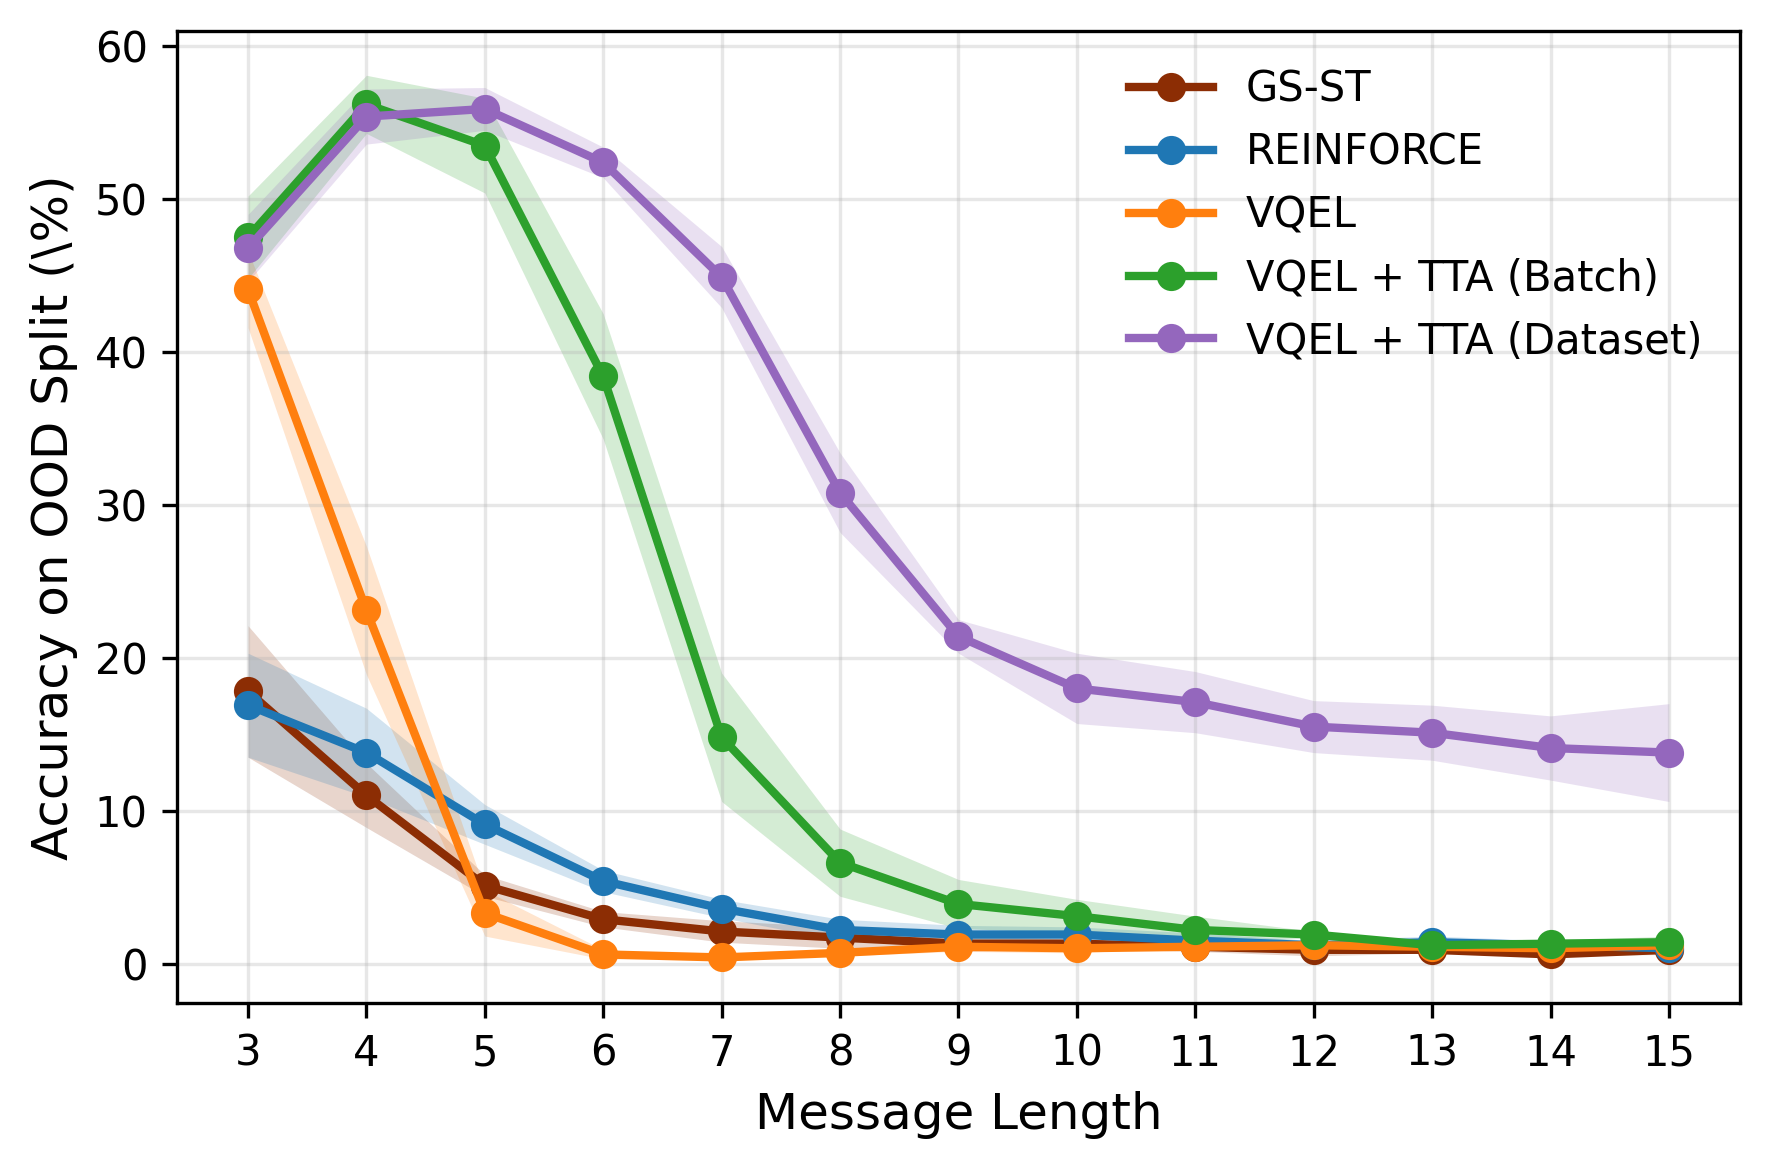

In [473]:
plot([gumbel3, REINFORCE3, VQ_NoTT3, batch_adapt3, dataset_adapt3], name="rlt/mnist_without_rlt_l3")

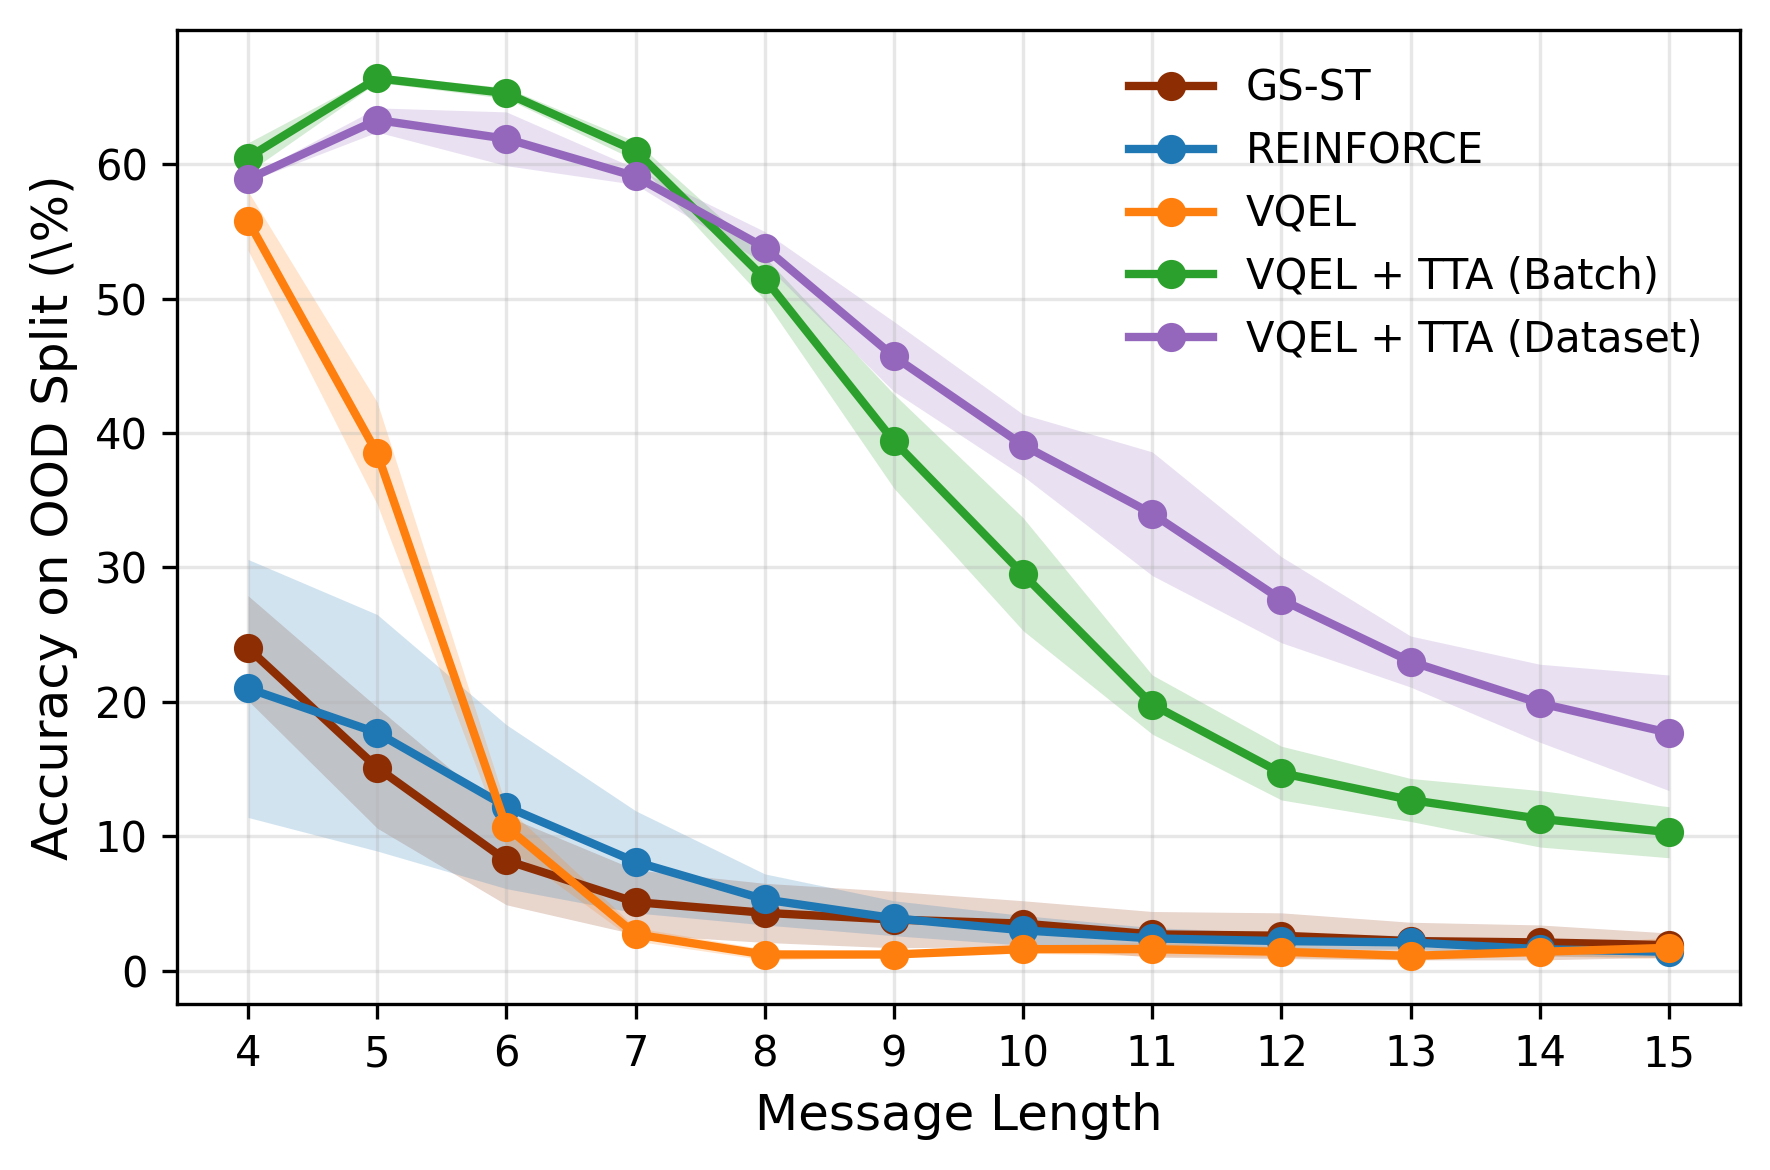

In [474]:
plot([gumbel4, REINFORCE4, VQ_NoTT4, batch_adapt4, dataset_adapt4], name="rlt/mnist_without_rlt_l4")

## ImageNet

### Gumbel - ID

In [475]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": True,
    "gumbel": True,
    "test_time_mode": "-",
    "dataset_tt": "imagenet",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "seed"])

res[gumbel_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase2_a,learning_rate_phase2_b,tau_0,mutual_play_accuracy,sampling_temperature,test_time_mode,path
0,1,True,imagenet,cosine,[3],-,1e-05,1e-01,87,1,-,20260528_0202_bs32_vocab10_repr2048_msg_len3_m...
1,2,True,imagenet,cosine,[3],-,1e-05,1e-01,86,1e-05,-,20260528_0226_bs32_vocab10_repr2048_msg_len3_m...
2,3,True,imagenet,cosine,[3],-,1e-05,1e-01,86.7,1e-05,-,20260528_0250_bs32_vocab10_repr2048_msg_len3_m...
3,1,True,imagenet,cosine,[4],-,1e-05,1e-01,91.8,1,-,20260527_0548_bs32_vocab10_repr2048_msg_len4_m...
4,2,True,imagenet,cosine,[4],-,1e-05,1e-01,92.4,1e-05,-,20260527_0615_bs32_vocab10_repr2048_msg_len4_m...
5,3,True,imagenet,cosine,[4],-,1e-05,1e-01,92.7,1e-05,-,20260527_0641_bs32_vocab10_repr2048_msg_len4_m...


In [476]:
mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["mutual_play_accuracy"])

,dataset,message_length,mutual_play_accuracy
0,imagenet,[3],86.6 ± 0.5
1,imagenet,[4],92.3 ± 0.5


### Gumbel - OOD

In [477]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": True,
    "gumbel": True,
    "test_time_mode": "-",
    "dataset_tt": "imagenet_same_class",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "message_length_tt", "seed"])

# res[baseline_cols]

In [478]:
gumbel = mean_and_std(res)
# gumbel

In [479]:
gumbel3 = gumbel.iloc[:13].reset_index(drop=True)
gumbel4 = gumbel.iloc[13:].reset_index(drop=True)

### REINFORCE - ID

In [480]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": True,
    "gumbel": False,
    "test_time_mode": "-",
    "dataset_tt": "imagenet",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "seed"])

res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,True,imagenet,cosine,[3],1e-05,-,1e-05,-,0,81.1,20260528_0314_bs32_vocab10_repr2048_msg_len3_m...
1,2,True,imagenet,cosine,[3],1e-05,-,1e-05,-,0,80.4,20260528_0338_bs32_vocab10_repr2048_msg_len3_m...
2,3,True,imagenet,cosine,[3],1e-05,-,1e-05,-,0,81.3,20260528_0401_bs32_vocab10_repr2048_msg_len3_m...
3,1,True,imagenet,cosine,[4],1e-05,-,1e-05,-,0,85.4,20260527_0926_bs32_vocab10_repr2048_msg_len4_m...
4,2,True,imagenet,cosine,[4],1e-05,-,1e-05,-,0,87.9,20260527_0956_bs32_vocab10_repr2048_msg_len4_m...
5,3,True,imagenet,cosine,[4],1e-05,-,1e-05,-,0,87,20260527_1026_bs32_vocab10_repr2048_msg_len4_m...


In [481]:
mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["mutual_play_accuracy"])

,dataset,message_length,mutual_play_accuracy
0,imagenet,[3],80.9 ± 0.5
1,imagenet,[4],86.8 ± 1.3


### REINFORCE - OOD

In [482]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": True,
    "gumbel": False,
    "test_time_mode": "-",
    "dataset_tt": "imagenet_same_class",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "message_length_tt", "seed"])

# res[baseline_cols]

In [483]:
REINFORCE = mean_and_std(res)
# REINFORCE

In [484]:
REINFORCE3 = REINFORCE.iloc[:13].reset_index(drop=True)
REINFORCE4 = REINFORCE.iloc[13:].reset_index(drop=True)

### VQEL - ID

In [485]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": False,
    "test_time_mode": "-",
    "dataset_tt": "imagenet",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "seed"])

res[backbone_cols]

,seed,baseline,dataset,sim,message_length,learning_rate_phase1,learning_rate_phase2_a,learning_rate_phase2_b,test_time_mode,self_play_accuracy_a,mutual_play_accuracy,path
0,1,False,imagenet,cosine,[3],1e-04,-,1e-04,-,83.2,82.8,20260528_0425_bs32_vocab10_repr2048_msg_len3_m...
1,2,False,imagenet,cosine,[3],1e-04,-,1e-04,-,83.5,84.3,20260528_0440_bs32_vocab10_repr2048_msg_len3_m...
2,3,False,imagenet,cosine,[3],1e-04,-,1e-04,-,84.6,84.7,20260528_0454_bs32_vocab10_repr2048_msg_len3_m...
3,1,False,imagenet,cosine,[4],1e-04,-,1e-04,-,92.3,92.1,20260527_0236_bs32_vocab10_repr2048_msg_len4_m...
4,2,False,imagenet,cosine,[4],1e-04,-,1e-04,-,92.7,91.1,20260527_0252_bs32_vocab10_repr2048_msg_len4_m...
5,3,False,imagenet,cosine,[4],1e-04,-,1e-04,-,91.7,92.4,20260527_0308_bs32_vocab10_repr2048_msg_len4_m...


In [486]:
mean_and_std(res, config_cols = ["dataset", "message_length"], metrics = ["self_play_accuracy_a", "mutual_play_accuracy"])

,dataset,message_length,self_play_accuracy_a,mutual_play_accuracy
0,imagenet,[3],83.8 ± 0.7,83.9 ± 1.0
1,imagenet,[4],92.2 ± 0.5,91.9 ± 0.7


### VQEL - OOD

In [487]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": False,
    "test_time_mode": "-",
    "dataset_tt": "imagenet_same_class",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "message_length_tt", "seed"])

# res[baseline_cols]

In [488]:
VQ_NoTT = mean_and_std(res)
VQ_NoTT

,dataset,message_length,message_length_tt,dataset_tt,test_time_mode,test_time_self_accuracy,test_time_mutual_accuracy
0,imagenet,[3],3,imagenet_same_class,-,75.2 ± 0.8,37.3 ± 1.6
1,imagenet,[3],4,imagenet_same_class,-,11.2 ± 3.0,9.3 ± 0.9
2,imagenet,[3],5,imagenet_same_class,-,4.4 ± 1.8,5.9 ± 1.2
3,imagenet,[3],6,imagenet_same_class,-,17.3 ± 6.3,7.3 ± 1.5
4,imagenet,[3],7,imagenet_same_class,-,1.6 ± 1.4,3.0 ± 1.7
5,imagenet,[3],8,imagenet_same_class,-,6.5 ± 1.2,4.9 ± 1.7
6,imagenet,[3],9,imagenet_same_class,-,4.7 ± 3.5,3.2 ± 1.6
7,imagenet,[3],10,imagenet_same_class,-,3.6 ± 1.5,4.6 ± 1.7
8,imagenet,[3],11,imagenet_same_class,-,9.9 ± 2.5,5.7 ± 0.3
9,imagenet,[3],12,imagenet_same_class,-,1.7 ± 1.4,2.4 ± 0.5


In [489]:
VQ_NoTT3 = VQ_NoTT.iloc[:13].reset_index(drop=True)
VQ_NoTT4 = VQ_NoTT.iloc[13:].reset_index(drop=True)

### Batch Adaptation

In [490]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": False,
    "test_time_mode": "batch_adaptation",
    "dataset_tt": "imagenet_same_class",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "message_length_tt", "seed"])

# res[adapt_cols]

In [491]:
batch_adapt = mean_and_std(res)
# batch_adapt

In [492]:
batch_adapt3 = batch_adapt.iloc[:13].reset_index(drop=True)
batch_adapt4 = batch_adapt.iloc[13:].reset_index(drop=True)

### Dataset Adaptation

In [493]:
res = filter_df({
    "dataset": "imagenet",
    "baseline": False,
    "test_time_mode": "dataset_adaptation",
    "dataset_tt": "imagenet_same_class",
    "message_length": ["[3]", "[4]"],
}, sort_by=["message_length", "message_length_tt", "seed"])

# res[adapt_cols]

In [494]:
dataset_adapt = mean_and_std(res)
# dataset_adapt

In [495]:
dataset_adapt3 = dataset_adapt.iloc[:13].reset_index(drop=True)
dataset_adapt4 = dataset_adapt.iloc[13:].reset_index(drop=True)

### Plot

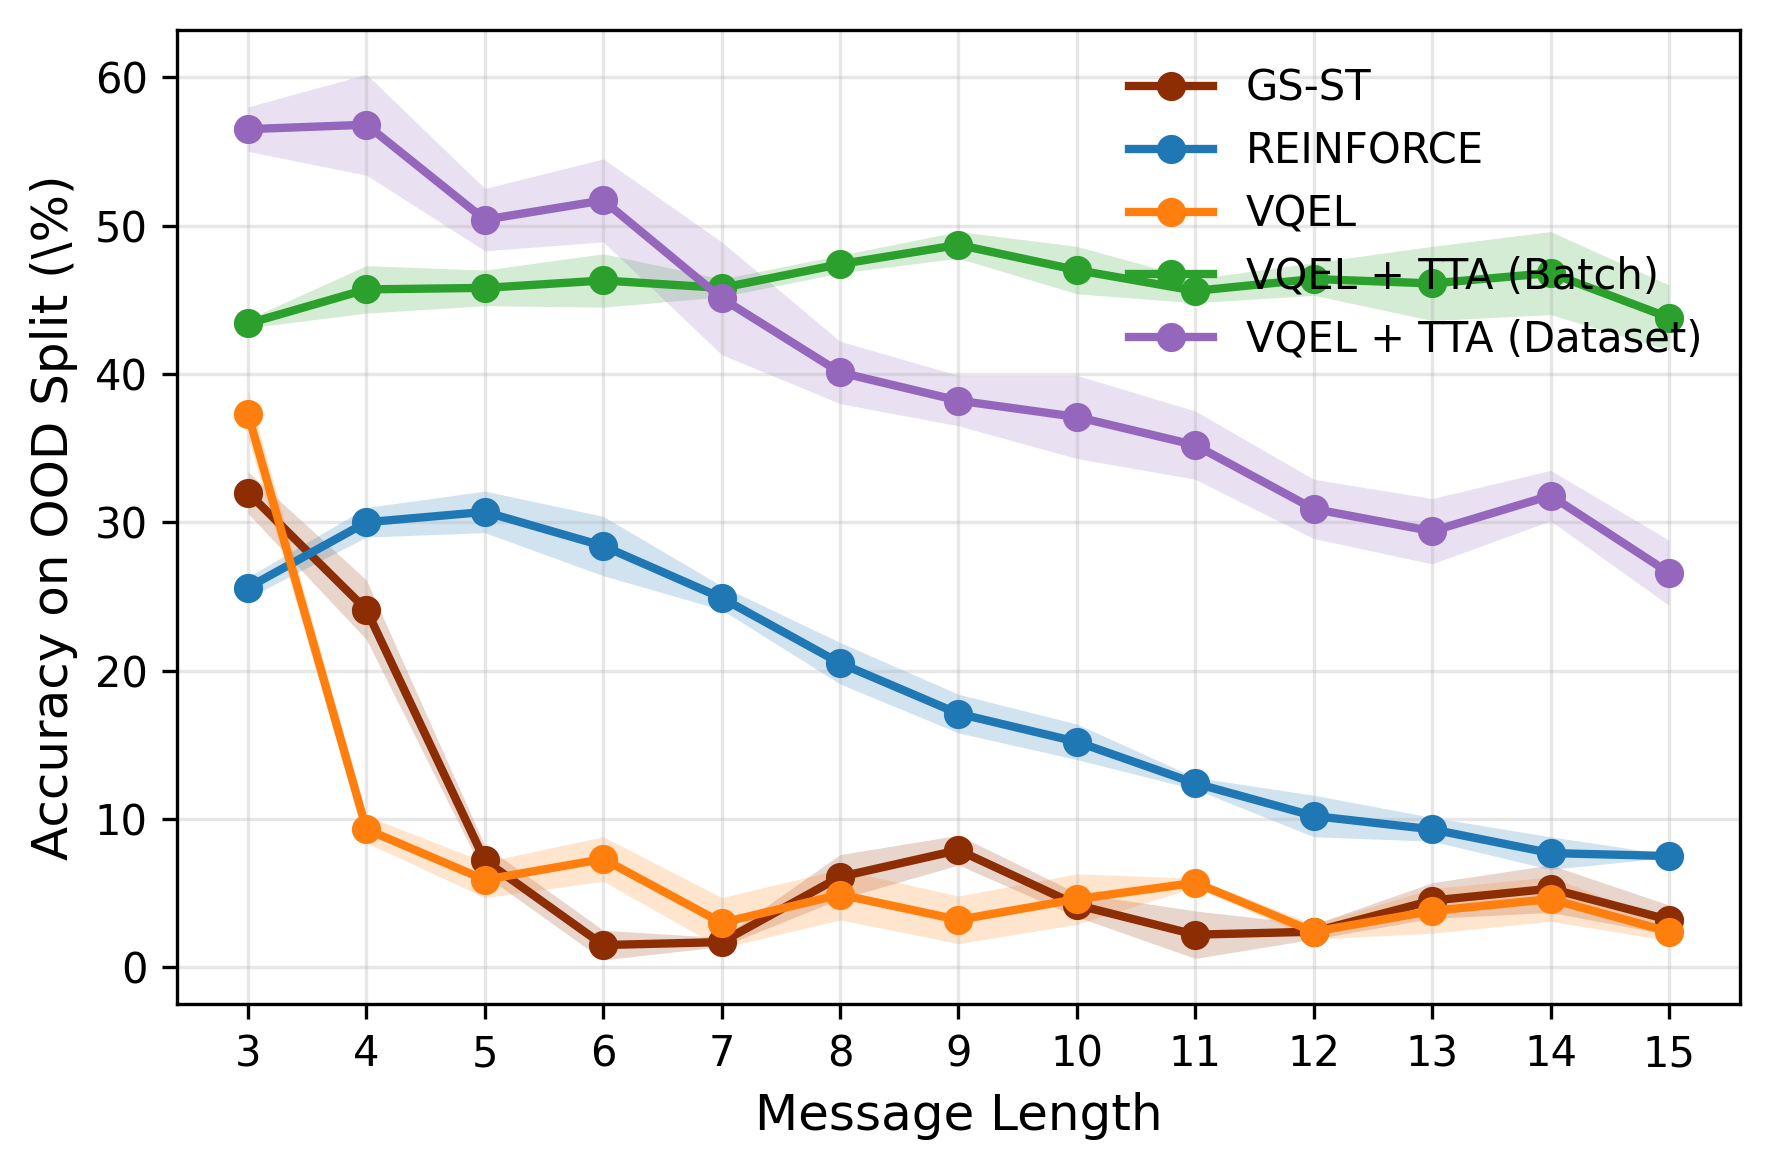

In [496]:
plot([gumbel3, REINFORCE3, VQ_NoTT3, batch_adapt3, dataset_adapt3], name="rlt/imagenet_without_rlt_l3")

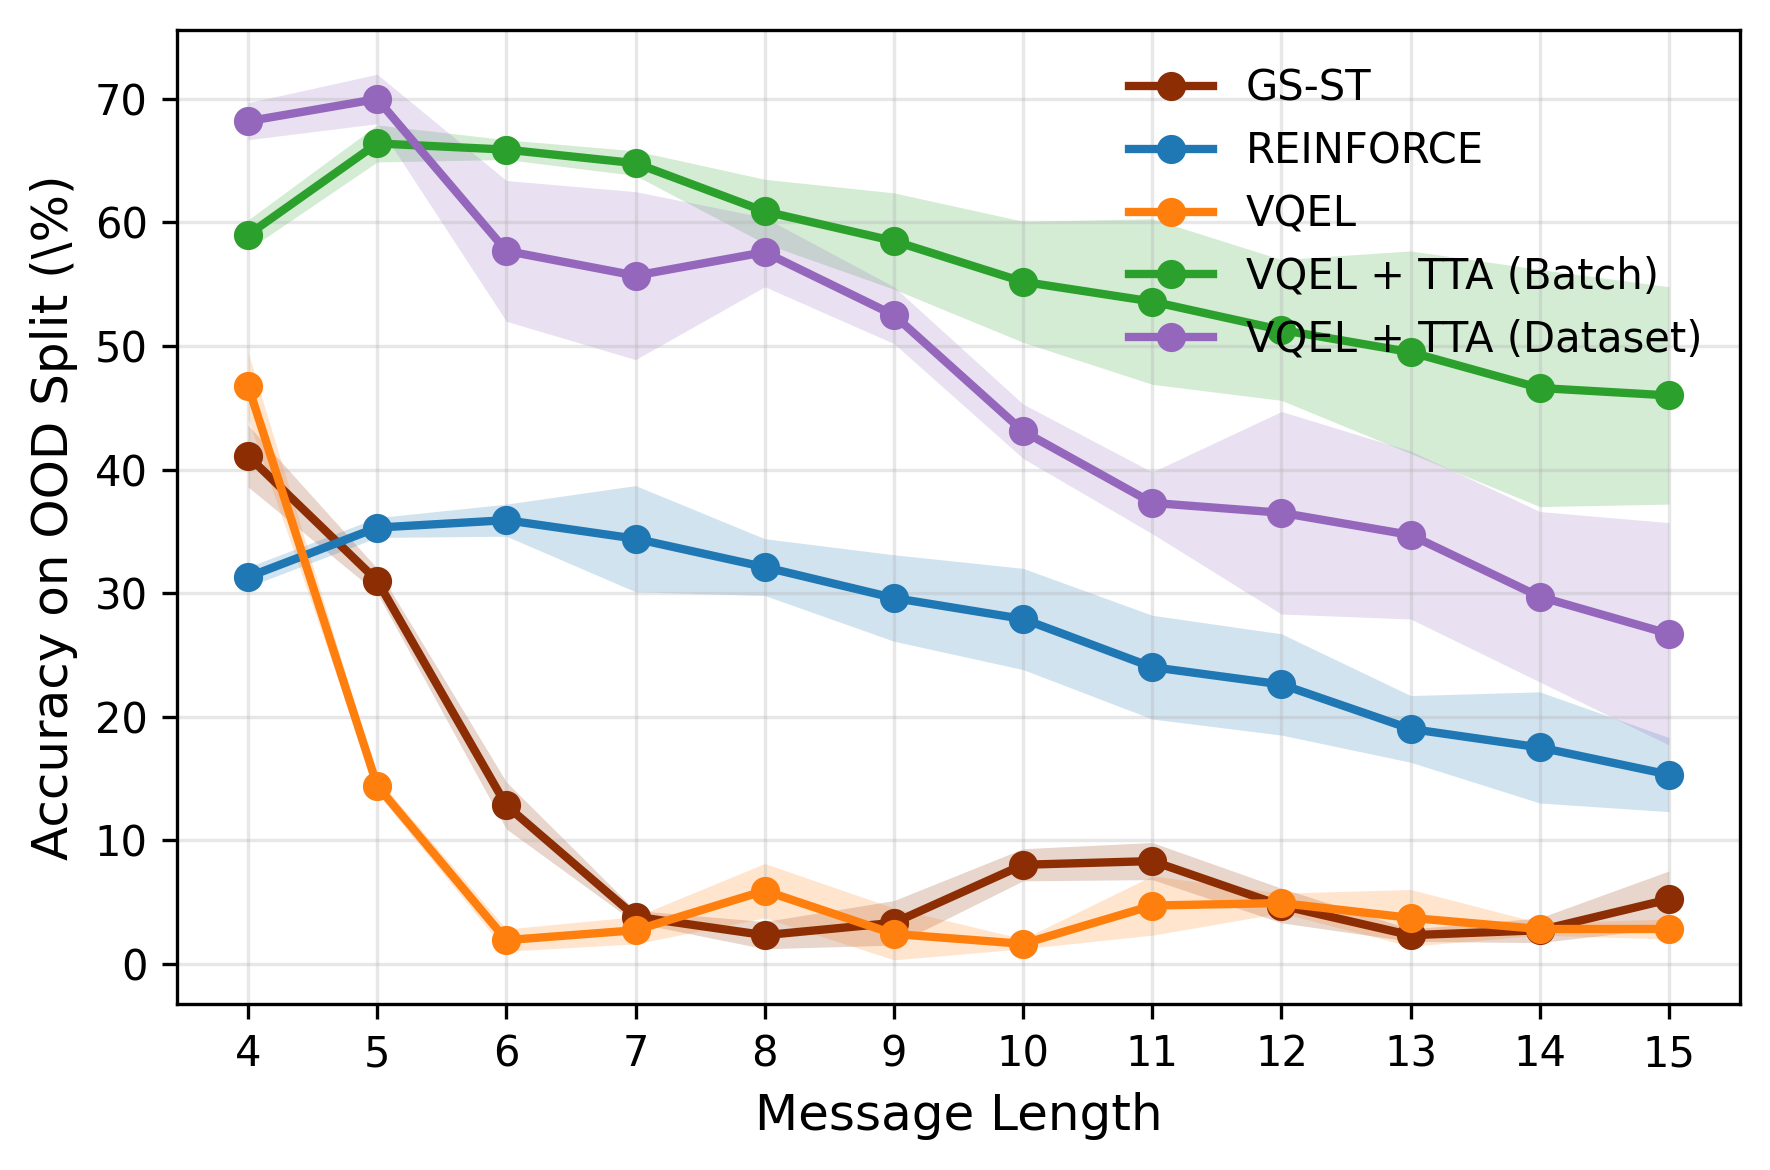

In [497]:
plot([gumbel4, REINFORCE4, VQ_NoTT4, batch_adapt4, dataset_adapt4], name="rlt/imagenet_without_rlt_l4")